## Notebook roadmap
This notebook reproduces **Figure 7** from the manuscript (old `figure_5.ipynb`).

Figure intent:
- compare in-distribution (`train=test`) and cross-distribution (`train!=test`) distance matrices,
- show HDBSCAN confidence profiles over coupling `J/t`,
- export publication-ready assets (`figure_7.pdf`, `figure_7.svg`).


In [1]:
import os
import pickle

import numpy as np
import torch as pt

%matplotlib widget
import matplotlib.colors as mcolors
from matplotlib import pyplot as plt
from matplotlib.cm import ScalarMappable
from matplotlib.ticker import AutoMinorLocator, FuncFormatter

from nestconf import Configurable
from sklearn.cluster import HDBSCAN

from utils.aggregation import aggregate_seeded_results


# Common settings
Set typography and global plotting style consistent with the other migrated figure notebooks.


In [2]:
AXES_LINEWIDTH = 2.0
TICK_SIZE = 10
LABEL_SIZE = 8

plt.rcParams.update({
    'text.usetex': True,
    'font.family': 'sans-serif',
    'text.latex.preamble': '\n'.join([
        r'\usepackage[semibold,sfdefault]{libertine}',
        r'\usepackage[libertine]{newtxmath}',
    ]),
    'axes.linewidth': AXES_LINEWIDTH,
})


# Distance data preparation
Load seeded distance-learning outputs from the localized Figure 7 dataset.


In [3]:
class Experiment(Configurable):
    """Schema used to deserialize pickled experiment-config keys."""

    system_size: int = None
    num_holes: int = None
    num_magnons: int = None


figure_data_dir = '../data/figures/figure_7/tj_ladders_cross_sector'

with open(os.path.join(figure_data_dir, 'seeded_f_matrices_dict.pickle'), 'rb') as handle:
    seeded_f_matrices_dict = pickle.load(handle)
with open(os.path.join(figure_data_dir, 'cross_seeded_f_matrices_dict.pickle'), 'rb') as handle:
    cross_seeded_f_matrices_dict = pickle.load(handle)
with open(os.path.join(figure_data_dir, 'coords_dict.pickle'), 'rb') as handle:
    coords_dict = pickle.load(handle)


## Aggregate seeded matrices
Aggregate per-seed tensors with the shared helper and keep matrices symmetric for plotting/clustering.


In [4]:
def aggregate_seeded_matrix_dict(seeded_dict, seeded_std_like_dict):
    """Aggregate each experiment/divergence matrix across seeds."""

    aggregated = {}
    aggregated_std = {}

    for exp_config in seeded_dict:
        aggregated[exp_config] = {}
        aggregated_std[exp_config] = {}

        for divergence in seeded_dict[exp_config]:
            seed_tensors = list(seeded_dict[exp_config][divergence].values())

            # Legacy files only store one seeded matrix dict for cross terms.
            # Use sample std over seeded means as a fallback SEM proxy when needed.
            if seeded_std_like_dict is None:
                stack = pt.stack(seed_tensors, dim=0)
                seeded_std_tensors = [
                    pt.std(stack, dim=0, unbiased=False) / pt.sqrt(pt.tensor(float(stack.shape[0])))
                    for _ in seed_tensors
                ]
            else:
                seeded_std_tensors = list(seeded_std_like_dict[exp_config][divergence].values())

            f_matrix, f_matrix_std, _, _ = aggregate_seeded_results(
                seeded_f_tensors=seed_tensors,
                seeded_std_tensors=seeded_std_tensors,
                verbose=False,
                use_inverse_variance_weighting=False,
            )

            f_matrix = 0.5 * (f_matrix + f_matrix.T)
            f_matrix_std = 0.5 * (f_matrix_std + f_matrix_std.T)

            aggregated[exp_config][divergence] = f_matrix
            aggregated_std[exp_config][divergence] = f_matrix_std

    return aggregated, aggregated_std


# The provided dataset has mean tensors for seeded and cross-seeded outputs.
# We use empirical seed scatter as fallback uncertainty proxy for aggregation.
f_matrices_dict, f_matrices_std_dict = aggregate_seeded_matrix_dict(
    seeded_dict=seeded_f_matrices_dict,
    seeded_std_like_dict=None,
)
cross_f_matrices_dict, cross_f_matrices_std_dict = aggregate_seeded_matrix_dict(
    seeded_dict=cross_seeded_f_matrices_dict,
    seeded_std_like_dict=None,
)


## Plot helpers
Define the cluster color mapping and compact tick formatting used by all panels.


In [5]:
class_to_colour = {
    -1: "black",          # mild grey  (noise / unassigned)
     0: "xkcd:periwinkle",  # blue
     1: "xkcd:peach",      # green
     2: "xkcd:bordeaux",       # orange
     3: 'xkcd:light red',
}
all_labels = [-1, 0, 1, 2,]
colour_list = [class_to_colour[label] for label in all_labels]

cluster_cmap = mcolors.ListedColormap(colour_list, name='cluster_cmap')
cluster_bounds = np.arange(len(all_labels) + 1) - 1.5
cluster_norm = mcolors.BoundaryNorm(cluster_bounds, cluster_cmap.N)
cluster_mappable = ScalarMappable(cmap=cluster_cmap, norm=cluster_norm)
cluster_mappable.set_array([])


def compact_axes(ax, x_tex=None, y_tex=None, xmin_label=None, xmax_label=None, ymin_label=None, ymax_label=None, bottom_only=False):
    """Show endpoint numeric ticks and one symbolic center label for compact panel layout."""

    xmin, xmax = ax.get_xlim()
    xmid = 0.5 * (xmin + xmax)

    def x_major_formatter_lambda(v, _):
        if np.isclose(v, xmin) and (xmin_label is not None):
            return xmin_label
        if np.isclose(v, xmax) and (xmax_label is not None):
            return xmax_label
        return x_tex or ''

    ax.xaxis.set_ticks([xmin, xmid, xmax])
    ax.xaxis.set_major_formatter(FuncFormatter(x_major_formatter_lambda))
    ax.xaxis.set_minor_locator(AutoMinorLocator())
    ax.tick_params(axis='x', which='major', labelsize=LABEL_SIZE, direction='in', bottom=True, top=False, length=4, pad=1)
    ax.tick_params(axis='x', which='minor', labelsize=LABEL_SIZE, direction='in', bottom=True, top=False, length=3, pad=1)
    ax.set_xlabel(None)

    if bottom_only:
        ax.tick_params(axis='x', labelsize=LABEL_SIZE, labelbottom=True, labeltop=False)
        ax.xaxis.set_label_position('bottom')

    ymin, ymax = ax.get_ylim()
    ymid = 0.5 * (ymin + ymax)

    def y_major_formatter_lambda(v, _):
        if np.isclose(v, ymin) and (ymin_label is not None):
            return ymin_label
        if np.isclose(v, ymax) and (ymax_label is not None):
            return ymax_label
        return y_tex or ''

    ax.yaxis.set_ticks([ymin, ymid, ymax])
    ax.yaxis.set_major_formatter(FuncFormatter(y_major_formatter_lambda))
    ax.yaxis.set_minor_locator(AutoMinorLocator())
    ax.tick_params(axis='y', which='major', labelsize=LABEL_SIZE, direction='in', left=True, right=True, length=4, pad=1)
    ax.tick_params(axis='y', which='minor', labelsize=LABEL_SIZE, direction='in', left=True, right=True, length=3, pad=1)
    ax.set_ylabel(None)


def tensor_to_numpy(x):
    """Convert torch tensors (or NumPy-like objects) to NumPy arrays for plotting/sklearn."""

    if isinstance(x, pt.Tensor):
        return x.detach().cpu().numpy()
    return np.asarray(x)


def find_target_config(*, source_dict, system_size, num_holes, num_magnons):
    """Pick the experiment config matching the requested physical parameters."""

    for exp_config in source_dict:
        if (
            exp_config.system_size == system_size
            and exp_config.num_holes == num_holes
            and exp_config.num_magnons == num_magnons
        ):
            return exp_config
    raise ValueError(
        f'No config found for system_size={system_size}, num_holes={num_holes}, num_magnons={num_magnons}'
    )


# Build and export figure
Render the 2x4 panel layout and save Figure 7 as PDF/SVG.


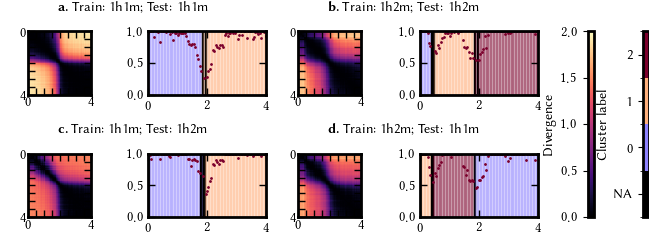

In [6]:
FIG_WIDTH_CM = 16.5
FIG_HEIGHT_CM = 6.0
CM_TO_INCH = 1.0 / 2.54

fig = plt.figure(
    figsize=(FIG_WIDTH_CM * CM_TO_INCH, FIG_HEIGHT_CM * CM_TO_INCH),
    constrained_layout=True,
)
grid_spec = fig.add_gridspec(
    nrows=2,
    ncols=6,
    width_ratios=[1, 1, 1, 1, 0.05, 0.05],
)
fig.set_constrained_layout_pads(w_pad=0.01, h_pad=0.01, wspace=0.01, hspace=0.03)

axes = {}
for row_idx in range(2):
    for col_idx in range(4):
        axes[(row_idx, col_idx)] = fig.add_subplot(grid_spec[row_idx, col_idx])
dist_cbar_ax = fig.add_subplot(grid_spec[:, -2])
cluster_cbar_ax = fig.add_subplot(grid_spec[:, -1])

target_system_size = 100
range_for_num_magnons = (1, 2)
num_holes = 1

im = None
ax_labels = [
    r'$\textbf{a.}$ ',
    r'$\textbf{b.}$ ',
    r'$\textbf{c.}$ ',
    r'$\textbf{d.}$ ',
]
ax_idx = 0

for row_idx in range(2):
    for num_magnons_idx, num_magnons in enumerate(range_for_num_magnons):
        target_exp_config = find_target_config(
            source_dict=seeded_f_matrices_dict,
            system_size=target_system_size,
            num_holes=num_holes,
            num_magnons=num_magnons,
        )

        title_ax = fig.add_subplot(
            grid_spec[row_idx, 2 * num_magnons_idx: 2 * num_magnons_idx + 2],
            frame_on=False,
        )
        title_ax.set_xticks([])
        title_ax.set_yticks([])
        cross_num_magnons = 1 if num_magnons == 2 else 2
        title_ax.set_title(
            ax_labels[ax_idx] + (
                f'Train: 1h{num_magnons}m; Test: 1h{num_magnons}m'
                if row_idx == 0
                else f'Train: 1h{num_magnons}m; Test: 1h{cross_num_magnons}m'
            ),
            fontsize=LABEL_SIZE + 2,
            pad=15,
        )
        ax_idx += 1
        title_ax.set_zorder(-1)

        matrix_ax = axes[(row_idx, 2 * num_magnons_idx)]
        confidence_ax = axes[(row_idx, 2 * num_magnons_idx + 1)]

        matrix_tensor = (
            f_matrices_dict[target_exp_config]['hellinger']
            if row_idx == 0
            else cross_f_matrices_dict[target_exp_config]['hellinger']
        )
        matrix = tensor_to_numpy(matrix_tensor)

        im = matrix_ax.matshow(matrix, cmap='magma', vmin=0.0, vmax=2.0)

        cur_coords = np.asarray(coords_dict[target_exp_config])[:, 0]
        class_indices = [idx for idx in range(len(cur_coords)) if (idx % 25) == 0]
        class_names = [f'{cur_coords[idx]:.0f}' for idx in class_indices]
        matrix_ax.set_xticks(class_indices, class_names, fontsize=TICK_SIZE)
        matrix_ax.set_yticks(class_indices, class_names, fontsize=TICK_SIZE)
        matrix_ax.set_xlabel(r'$J/t$', fontsize=LABEL_SIZE)
        matrix_ax.set_ylabel(r'$J/t$', fontsize=LABEL_SIZE)

        compact_axes(
            matrix_ax,
            x_tex='',
            xmin_label=0,
            xmax_label=4,
            y_tex='',
            ymin_label=4,
            ymax_label=0,
            bottom_only=True,
        )

        # HDBSCAN expects a distance matrix when metric='precomputed'.
        hdbscan_model = HDBSCAN(metric='precomputed', copy=True)
        cluster_labels = hdbscan_model.fit_predict(np.sqrt(matrix))
        cluster_confidences = hdbscan_model.probabilities_

        confidence_ax.plot(
            cur_coords,
            cluster_confidences,
            c='xkcd:bordeaux',
            linestyle='',
            marker='o',
            ms=1,
        )
        confidence_ax.set_xlim((float(np.min(cur_coords)), float(np.max(cur_coords))))
        confidence_ax.set_ylim((0.0, 1.0))

        # Shade background by inferred cluster label.
        for coord_idx in range(len(cur_coords)):
            x_axis = cur_coords
            if coord_idx == 0:
                left_border = x_axis[0]
                right_border = 0.5 * (x_axis[1] + x_axis[0])
            elif coord_idx == len(x_axis) - 1:
                left_border = 0.5 * (x_axis[-1] + x_axis[-2])
                right_border = x_axis[-1]
            else:
                left_border = 0.5 * (x_axis[coord_idx] + x_axis[coord_idx - 1])
                right_border = 0.5 * (x_axis[coord_idx] + x_axis[coord_idx + 1])

            cur_label = int(cluster_labels[coord_idx])
            span_color = class_to_colour.get(cur_label, 'xkcd:light grey')
            span_alpha = 1.0 if cur_label == -1 else 0.25
            confidence_ax.axvspan(left_border, right_border, color=span_color, alpha=span_alpha)

dist_cbar = fig.colorbar(im, cax=dist_cbar_ax, orientation='vertical')
dist_cbar.set_label('Divergence', fontsize=LABEL_SIZE + 2, rotation=90)
dist_cbar.ax.yaxis.set_ticks_position('left')
dist_cbar.ax.yaxis.set_label_position('left')

cluster_tick_labels = ['NA' if label == -1 else f'{label}' for label in all_labels]

cluster_cbar = fig.colorbar(
    cluster_mappable,
    cax=cluster_cbar_ax,
    orientation='vertical',
    ticks=all_labels,
)
cluster_cbar.set_ticks(all_labels)
cluster_cbar.set_ticklabels(cluster_tick_labels)
cluster_cbar.set_label('Cluster label', fontsize=LABEL_SIZE + 2, rotation=90)
cluster_cbar.ax.yaxis.set_ticks_position('left')
cluster_cbar.ax.yaxis.set_label_position('left')

for ax in axes.values():
    ax.tick_params(
        axis='both',
        which='both',
        direction='in',
        labelsize=TICK_SIZE,
        width=0.5 * AXES_LINEWIDTH,
        size=5,
        top=True,
        right=True,
    )

fig.savefig('./figure_7.pdf', bbox_inches='tight', pad_inches=0.00)
fig.savefig('./figure_7.svg', bbox_inches='tight', pad_inches=0.00)
